# Étude de cas — Deux portefeuilles ($100,000) sur 5 ans (10 actions)
**Auteur :** RAKOTOMALALA Hasina Johary — projet pédagogique pour démontrer les compétences en Data Science & Finance

**Date :** 25/11/2025

**Objectif :** Construire et comparer deux portefeuilles investissant 100 000$ sur 10 actions :
1. Portefeuille A : pondération égale  
2. Portefeuille B : portefeuille optimisé (maximisation du Sharpe ratio) à partir de 20000 scénarios aléatoires

**Données :** prix ajustés (splits/dividendes pris en compte) — 5 dernières années via `yfinance`.

---

## Plan
1. Préparation des données  
2. Analyse exploratoire et calcul des rendements  
3. Construction du portefeuille égal-pondéré et évaluation (valeur, rendement, volatilité)  
4. Génération de 20000 portefeuilles aléatoires, calcul des statistiques et identification du portefeuille optimal (max Sharpe)  
5. Visualisation des résultats (nuage, Sharpe, points optimaux)  
6. Allocation finale pour 100 000$  
7. Conclusions & pièges fréquents


# 2. Analyse exploratoire & calcul des rendements

Dans cette section, nous réalisons une première exploration du dataset :

- Visualisation des premières lignes
- Vérification des valeurs manquantes
- Statistiques descriptives
- Calcul des rendements journaliers
- Calcul des rendements annuels moyens
- Matrice de corrélation entre les actifs

Les données utilisées proviennent du fichier :  
`data/adj_close_5y.csv`

---


Aperçu des données :


,AAPL,AMD,AMZN,GOOGL,JPM,META,MSFT,NVDA,ORCL,TSLA
Date,,,,,,,,,,
2020-11-27,113.494804,87.190002,159.766998,88.738960,106.464348,276.107880,206.521744,13.220892,53.875389,195.253326
2020-11-30,115.889496,92.660004,158.401993,87.119133,103.530914,275.273010,205.408707,13.360716,53.838081,189.199997
2020-12-01,119.462074,92.629997,161.003998,89.153099,105.164505,284.794312,207.462128,13.349249,54.789486,194.919998
2020-12-02,119.812515,93.739998,160.176498,90.623459,107.184540,285.758362,206.656082,13.503279,55.106613,189.606674
2020-12-03,119.676216,92.309998,159.336502,90.468033,106.481926,280.123138,205.571823,13.359178,55.283840,197.793335


Valeurs manquantes :
Aucune valeur manquante

Statistiques descriptives (prix ajustés) :


,AAPL,AMD,AMZN,GOOGL,JPM,META,MSFT,NVDA,ORCL,TSLA
count,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000
mean,176.529184,118.651643,162.018542,141.285076,169.781864,379.257438,337.346156,63.878437,115.939609,260.703312
std,38.382202,38.073112,39.247194,39.756958,58.742177,183.552980,88.946349,55.573538,55.261866,72.479635
min,113.440178,55.939999,81.820000,82.858528,94.695007,88.365257,202.002289,11.213528,53.838081,108.099998
25%,145.344475,90.147501,131.932499,113.088017,128.829750,235.592648,258.414909,18.740389,76.112223,209.157501
50%,170.930656,110.180000,164.393997,135.494987,142.991371,328.375656,321.142609,37.627260,98.813927,245.886665
75%,206.025681,144.464996,185.984253,163.678524,204.875931,517.139847,411.851463,115.685446,138.175701,302.569153
max,275.920013,264.329987,254.000000,318.579987,320.410004,789.467163,541.057373,207.039993,327.761200,479.859985



Aperçu des rendements journaliers :


,AAPL,AMD,AMZN,GOOGL,JPM,META,MSFT,NVDA,ORCL,TSLA
Date,,,,,,,,,,
2020-11-30,0.021100,0.062737,-0.008544,-0.018254,-0.027553,-0.003024,-0.005389,0.010576,-0.000692,-0.031002
2020-12-01,0.030827,-0.000324,0.016427,0.023347,0.015779,0.034589,0.009997,-0.000858,0.017672,0.030233
2020-12-02,0.002933,0.011983,-0.005140,0.016493,0.019208,0.003385,-0.003885,0.011538,0.005788,-0.027259
2020-12-03,-0.001138,-0.015255,-0.005244,-0.001715,-0.006555,-0.019720,-0.005247,-0.010672,0.003216,0.043177
2020-12-04,-0.005612,0.018741,-0.007578,0.001054,0.009073,-0.007628,0.000560,0.012112,0.011642,0.009539



Rendements annuels moyens :


AAPL     0.218044
AMD      0.316948
AMZN     0.131693
GOOGL    0.305501
JPM      0.236377
META     0.255798
MSFT     0.200096
NVDA     0.662990
ORCL     0.334162
TSLA     0.338450
dtype: float64

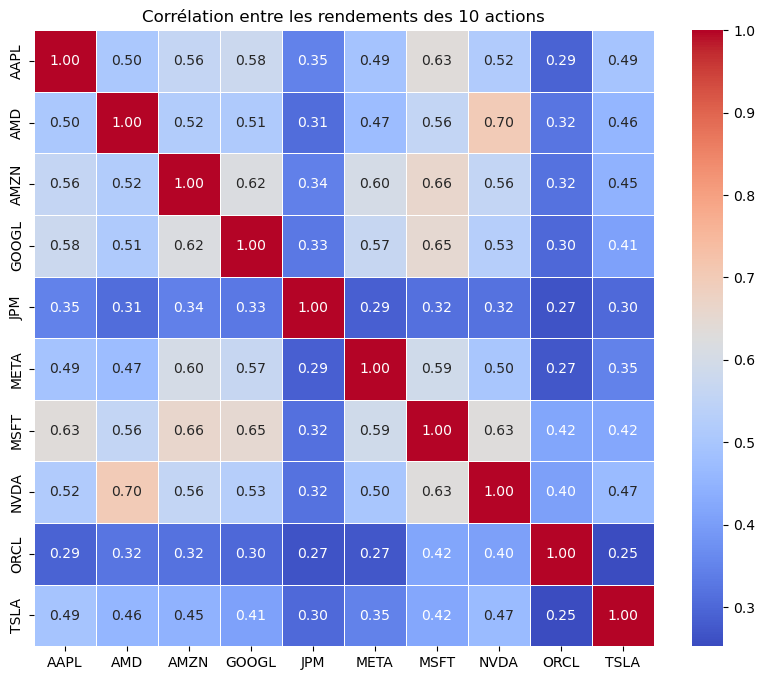

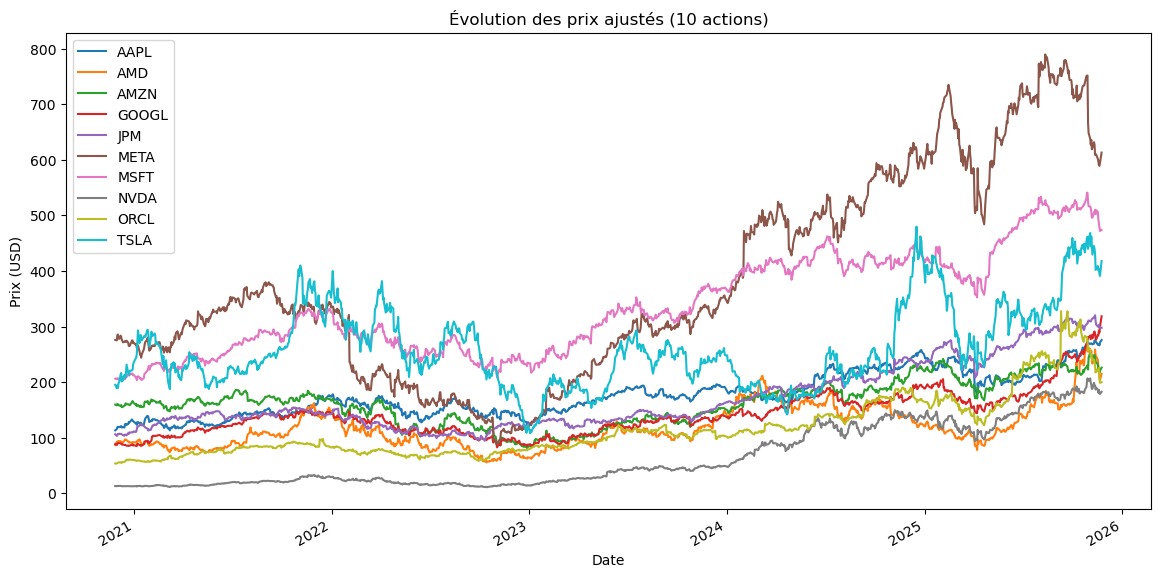

In [10]:
# ================================================================
# Étape 2 — Analyse exploratoire & calcul des rendements
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------
# 1. Charger les données propres
# ---------------------------------------------------------------

# Remplacer par ton chemin exact
csv_path = r"C:\Users\LENOVO\Dropbox\Mon PC (CNaPD-TT-130)\Desktop\BIDA\Python Fundamentals\Python Fundamentals - Learner Files\Python Fundamentals - Learner Files\C6 - Mon portfolio\data\adj_close_5y.csv"

# Charger le CSV
df = pd.read_csv(csv_path, index_col=0, parse_dates=True)


print("Aperçu des données :")
display(df.head())

# ---------------------------------------------------------------
# 2. Vérification des données manquantes
# ---------------------------------------------------------------

missing = df.isna().sum()
print("Valeurs manquantes :")
print(missing[missing > 0] if missing.sum() > 0 else "Aucune valeur manquante")

# ---------------------------------------------------------------
# 3. Statistiques descriptives
# ---------------------------------------------------------------

print("\nStatistiques descriptives (prix ajustés) :")
display(df.describe())

# ---------------------------------------------------------------
# 4. Calcul des rendements journaliers
# ---------------------------------------------------------------

returns = df.pct_change().dropna()

print("\nAperçu des rendements journaliers :")
display(returns.head())

# ---------------------------------------------------------------
# 5. Calcul des rendements annuels moyens
# ---------------------------------------------------------------

annual_returns = returns.mean() * 252
print("\nRendements annuels moyens :")
display(annual_returns)

# ---------------------------------------------------------------
# 6. Matrice de corrélation
# ---------------------------------------------------------------

plt.figure(figsize=(10, 8))
sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Corrélation entre les rendements des 10 actions")
plt.show()

# ---------------------------------------------------------------
# 7. Visualisation des prix
# ---------------------------------------------------------------

df.plot(figsize=(14, 7), title="Évolution des prix ajustés (10 actions)")
plt.xlabel("Date")
plt.ylabel("Prix (USD)")
plt.show()


# 3. Portefeuille égal-pondéré

Nous construisons un portefeuille **égal-pondéré** de 100 000 $ sur nos 10 actions.  

- Chaque action reçoit **10% du capital** : 10 000 $ chacune.  
- Objectif : calculer la **valeur du portefeuille dans le temps**, la **volatilité**, le **rendement annuel moyen** et le **Sharpe Ratio**.  

Le Sharpe Ratio est calculé avec un **taux sans risque de 0%** pour simplifier cette étude.


Portefeuille égal-pondéré (100 000 $)
-------------------------------------
Rendement annuel moyen : 30.00%
Volatilité annuelle : 28.06%
Sharpe Ratio : 1.07


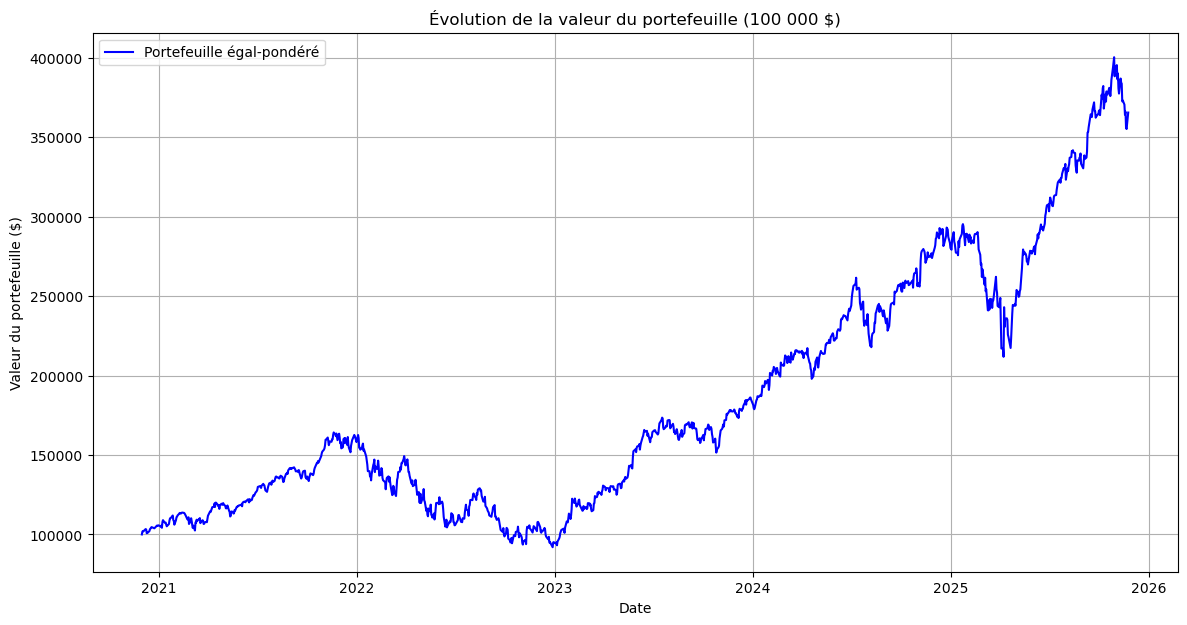

In [13]:
# ================================================================
# Étape 3 — Portefeuille égal-pondéré
# ================================================================
# Capital total
total_capital = 100000

# Nombre d'actions
n_assets = len(df.columns)

# Poids égaux
weights_equal = np.array([1/n_assets]*n_assets)

# ---------------------------------------------------------------
# 1. Calcul du rendement journalier du portefeuille
# ---------------------------------------------------------------
portfolio_returns = (returns * weights_equal).sum(axis=1)

# ---------------------------------------------------------------
# 2. Calcul de la valeur du portefeuille dans le temps
# ---------------------------------------------------------------
portfolio_value = total_capital * (1 + portfolio_returns).cumprod()

# ---------------------------------------------------------------
# 3. Statistiques du portefeuille
# ---------------------------------------------------------------
mean_daily_return = portfolio_returns.mean()
vol_daily = portfolio_returns.std()

annual_return = mean_daily_return * 252
annual_vol = vol_daily * np.sqrt(252)

sharpe_ratio = annual_return / annual_vol  # risk-free rate = 0

print("Portefeuille égal-pondéré (100 000 $)")
print("-------------------------------------")
print(f"Rendement annuel moyen : {annual_return:.2%}")
print(f"Volatilité annuelle : {annual_vol:.2%}")
print(f"Sharpe Ratio : {sharpe_ratio:.2f}")

# ---------------------------------------------------------------
# 4. Visualisation de la valeur du portefeuille
# ---------------------------------------------------------------
plt.figure(figsize=(14,7))
plt.plot(portfolio_value, label="Portefeuille égal-pondéré", color="blue")
plt.title("Évolution de la valeur du portefeuille (100 000 $)")
plt.xlabel("Date")
plt.ylabel("Valeur du portefeuille ($)")
plt.legend()
plt.grid(True)
plt.show()


# 4. Simulation de portefeuilles aléatoires (20 000) et optimisation

Pour identifier le **portefeuille optimal**, nous allons :

1. Générer **20 000 portefeuilles** avec des poids aléatoires pour les 10 actions.  
2. Calculer pour chaque portefeuille :
   - Rendement annuel moyen  
   - Volatilité annuelle  
   - Sharpe Ratio (taux sans risque = 0%)  
3. Identifier le **portefeuille avec le Sharpe Ratio maximal**.  
4. Visualiser les résultats avec un **nuage de points rendement vs volatilité** et mettre en évidence le portefeuille optimal.


Portefeuille optimal (max Sharpe Ratio)
---------------------------------------
AAPL     0.097061
AMD      0.005402
AMZN     0.007078
GOOGL    0.226233
JPM      0.183243
META     0.027058
MSFT     0.013845
NVDA     0.204118
ORCL     0.205395
TSLA     0.030566
Name: 2608, dtype: float64

Rendement annuel : 36.02%
Volatilité annuelle : 26.31%
Sharpe Ratio : 1.37


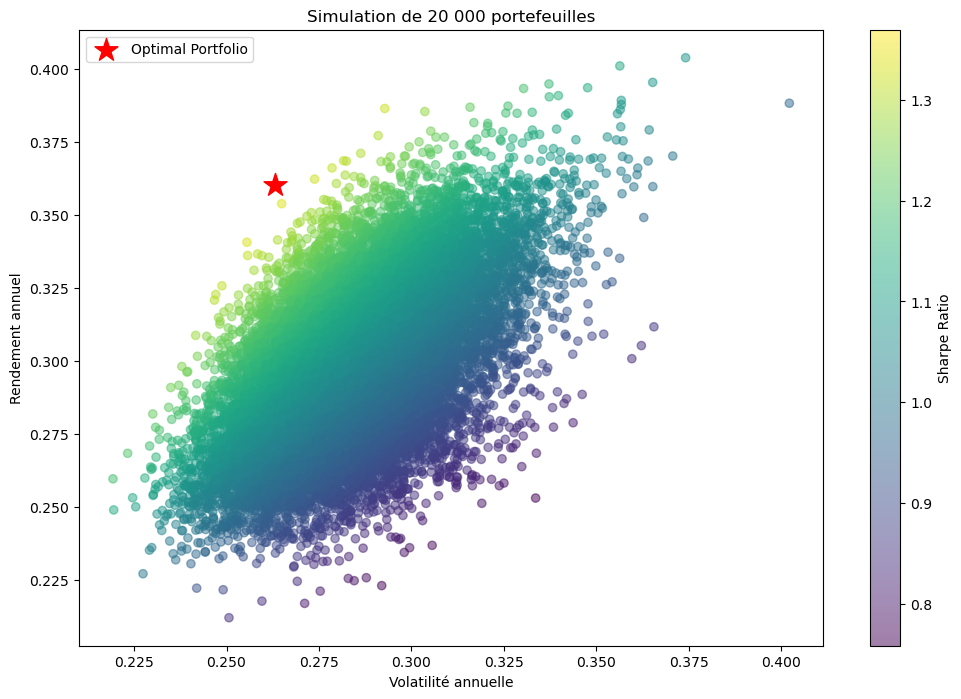

In [16]:
# ================================================================
# Étape 4 — Simulation de portefeuilles aléatoires
# ================================================================

n_portfolios = 20000
results = np.zeros((n_portfolios, 3))  # colonnes: rendement, vol, sharpe
weights_record = []

np.random.seed(42)  # reproductible

for i in range(n_portfolios):
    # Générer des poids aléatoires
    weights = np.random.random(n_assets)
    weights /= np.sum(weights)  # normaliser pour que somme = 1
    weights_record.append(weights)
    
    # Rendement et volatilité
    port_return = np.sum(annual_returns * weights)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))
    
    # Sharpe ratio
    sharpe = port_return / port_vol
    
    results[i] = [port_return, port_vol, sharpe]

# Convertir en DataFrame
results_df = pd.DataFrame(results, columns=["Return", "Volatility", "Sharpe"])
weights_df = pd.DataFrame(weights_record, columns=df.columns)

# Identifier le portefeuille optimal (max Sharpe)
max_sharpe_idx = results_df["Sharpe"].idxmax()
optimal_weights = weights_df.loc[max_sharpe_idx]
optimal_stats = results_df.loc[max_sharpe_idx]

print("Portefeuille optimal (max Sharpe Ratio)")
print("---------------------------------------")
print(optimal_weights)
print(f"\nRendement annuel : {optimal_stats['Return']:.2%}")
print(f"Volatilité annuelle : {optimal_stats['Volatility']:.2%}")
print(f"Sharpe Ratio : {optimal_stats['Sharpe']:.2f}")

# ---------------------------------------------------------------
# Visualisation
# ---------------------------------------------------------------

plt.figure(figsize=(12,8))
plt.scatter(results_df["Volatility"], results_df["Return"], c=results_df["Sharpe"], cmap="viridis", alpha=0.5)
plt.colorbar(label="Sharpe Ratio")
plt.scatter(optimal_stats["Volatility"], optimal_stats["Return"], color="red", marker="*", s=300, label="Optimal Portfolio")
plt.xlabel("Volatilité annuelle")
plt.ylabel("Rendement annuel")
plt.title("Simulation de 20 000 portefeuilles")
plt.legend()
plt.show()


# 5. Allocation finale et visualisation des portefeuilles

Dans cette étape, nous :

1. Calculons la **valeur cumulée** des deux portefeuilles :
   - Portefeuille A : égal-pondéré (10% par action)  
   - Portefeuille B : portefeuille optimal (max Sharpe)
2. Visualisons la **valeur du portefeuille dans le temps**.
3. Comparons les **rendements annuels moyens**, **volatilité**, et **Sharpe Ratio** des deux portefeuilles.
4. Fournissons une table d’**allocation finale pour 100 000 $**.


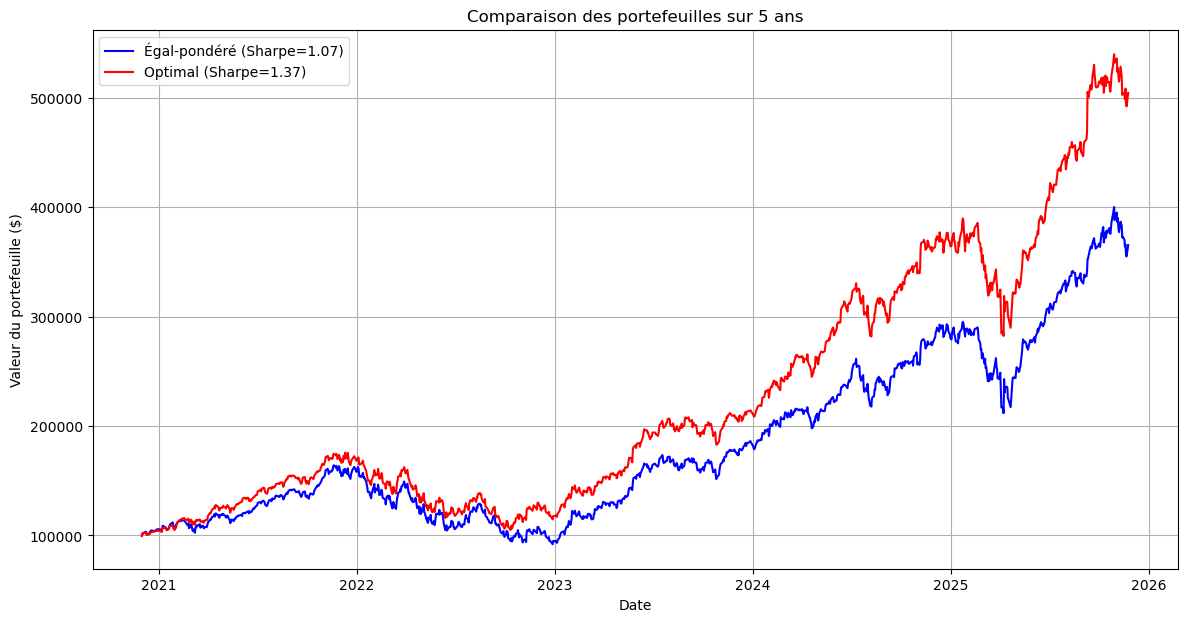

📊 Allocation finale - Portefeuille égal-pondéré


,Montant ($)
AAPL,10000.0
AMD,10000.0
AMZN,10000.0
GOOGL,10000.0
JPM,10000.0
META,10000.0
MSFT,10000.0
NVDA,10000.0
ORCL,10000.0
TSLA,10000.0


📊 Allocation finale - Portefeuille optimal


,Montant ($)
AAPL,9706.12
AMD,540.20
AMZN,707.84
GOOGL,22623.31
JPM,18324.30
META,2705.76
MSFT,1384.51
NVDA,20411.81
ORCL,20539.51
TSLA,3056.65


,Portefeuille,Rendement annuel,Volatilité annuelle,Sharpe Ratio
0,Égal-pondéré,0.30,0.28,1.07
1,Optimal,0.36,0.26,1.37


In [33]:
# ================================================================
# Étape 5 — Allocation finale et visualisation
# ================================================================

# Capital total
total_capital = 100000

# --- Portefeuille A : égal-pondéré ---
weights_equal = np.array([1/n_assets]*n_assets)
portfolio_returns_equal = (returns * weights_equal).sum(axis=1)
portfolio_value_equal = total_capital * (1 + portfolio_returns_equal).cumprod()

# Statistiques
annual_return_equal = portfolio_returns_equal.mean() * 252
annual_vol_equal = portfolio_returns_equal.std() * np.sqrt(252)
sharpe_equal = annual_return_equal / annual_vol_equal

# --- Portefeuille B : optimal ---
weights_optimal = optimal_weights.values
portfolio_returns_optimal = (returns * weights_optimal).sum(axis=1)
portfolio_value_optimal = total_capital * (1 + portfolio_returns_optimal).cumprod()

# Statistiques
annual_return_optimal = portfolio_returns_optimal.mean() * 252
annual_vol_optimal = portfolio_returns_optimal.std() * np.sqrt(252)
sharpe_optimal = annual_return_optimal / annual_vol_optimal

# ---------------------------------------------------------------
# Visualisation des deux portefeuilles
# ---------------------------------------------------------------

plt.figure(figsize=(14,7))
plt.plot(portfolio_value_equal, label=f"Égal-pondéré (Sharpe={sharpe_equal:.2f})", color="blue")
plt.plot(portfolio_value_optimal, label=f"Optimal (Sharpe={sharpe_optimal:.2f})", color="red")
plt.title("Comparaison des portefeuilles sur 5 ans")
plt.xlabel("Date")
plt.ylabel("Valeur du portefeuille ($)")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------------
# Allocation finale pour 100 000 $
# ---------------------------------------------------------------

allocation_equal = pd.DataFrame(np.round(weights_equal * total_capital, 2), index=df.columns, columns=["Montant ($)"])
allocation_optimal = pd.DataFrame(np.round(weights_optimal * total_capital, 2), index=df.columns, columns=["Montant ($)"])

print("📊 Allocation finale - Portefeuille égal-pondéré")
display(allocation_equal)

print("📊 Allocation finale - Portefeuille optimal")
display(allocation_optimal)

# ---------------------------------------------------------------
# Comparaison des statistiques
# ---------------------------------------------------------------
stats = pd.DataFrame({
    "Portefeuille": ["Égal-pondéré", "Optimal"],
    "Rendement annuel": [annual_return_equal, annual_return_optimal],
    "Volatilité annuelle": [annual_vol_equal, annual_vol_optimal],
    "Sharpe Ratio": [sharpe_equal, sharpe_optimal]
})

display(round(stats,2))


# 6. Conclusions et pièges fréquents

## Conclusions

- Le **portefeuille optimal** (max Sharpe Ratio) offre un **meilleur rendement ajusté au risque** que le portefeuille égal-pondéré.  
- La simulation avec 20 000 portefeuilles est suffisante pour identifier une allocation optimale sur 10 actions.  
- L’analyse illustre l’importance de **la diversification et de l’optimisation des poids** pour maximiser le Sharpe Ratio.  
- Les visualisations (valeur du portefeuille, nuage rendement-volatilité) permettent de **comparer facilement les deux portefeuilles**.

## Pièges fréquents

1. **Ne pas vérifier les données** : les prix ajustés doivent être utilisés pour inclure splits et dividendes.  
2. **Somme des poids différente de 1** : toujours normaliser les poids pour chaque portefeuille simulé.  
3. **Taux sans risque** : ici on l’a mis à 0 pour simplifier, mais dans la vraie vie, il faut l’inclure.  
4. **Nombre de scénarios insuffisant** : pour 10 actions, 20 000 portefeuilles suffisent, mais plus d’actions peuvent nécessiter plus de simulations.  
5. **Mauvaise interprétation du Sharpe Ratio** : il mesure le rendement par unité de risque, pas le rendement absolu.
